In [60]:
import json

qos_requirement = 30.0
num_users = 12
tau = 5.0

#seed

import numpy as np
np.random.seed(42)



with open(f'cumulative/agent_dynamics_{qos_requirement}_{num_users}_{tau}.json', 'r') as f:
    agent_dynamics = json.load(f)
    
agent_dynamics.keys()
def sort_keys(agent_dynamics):
    return {
        'ppo_diffusion': agent_dynamics['ppo_diffusion'],
        'ql_diffusion': agent_dynamics['ql_diffusion'],
        'gaussian_ppo': agent_dynamics['gaussian_ppo'],
        'gaussian_dql': agent_dynamics['gaussian_dql'],
    }
    
agent_dynamics = sort_keys(agent_dynamics)

x_axis = agent_dynamics["gaussian_dql"]["timesteps"]

y_axis_revenues = {
    "gaussian_ppo": agent_dynamics["gaussian_ppo"]["revenues"],
    "ql_diffusion": agent_dynamics["ql_diffusion"]["revenues"],
    "ppo_diffusion": agent_dynamics["ppo_diffusion"]["revenues"],
    "gaussian_dql": agent_dynamics["gaussian_dql"]["revenues"]
}

y_axis_users_serveed = {
    "ppo_diffusion": agent_dynamics["ppo_diffusion"]["users_served"],
    "ql_diffusion": agent_dynamics["ql_diffusion"]["users_served"],
    "gaussian_ppo": agent_dynamics["gaussian_ppo"]["users_served"],
    "gaussian_dql": agent_dynamics["gaussian_dql"]["users_served"]
}

y_axis_current_memory = {
    "ppo_diffusion": agent_dynamics["ppo_diffusion"]["current_memory"],
    "ql_diffusion": agent_dynamics["ql_diffusion"]["current_memory"],
    "gaussian_ppo": agent_dynamics["gaussian_ppo"]["current_memory"],
    "gaussian_dql": agent_dynamics["gaussian_dql"]["current_memory"]
}


In [61]:
COLOR_SCHEME_1 = {
    'gaussian_dql': 'tab:green',
    'gaussian_ppo': 'tab:blue', 
    'ql_diffusion': 'tab:orange',
    'ppo_diffusion': 'tab:red',
}

agent_names_display = {
    'ppo_diffusion': 'GSRM-DiPO',
    'ql_diffusion': 'GSRM-DiQL',
    'gaussian_ppo': 'GSRM-PPO',
    'gaussian_dql': 'GSRM-DQL',
}

In [62]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use("default")  

plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

plt.rcParams['font.family'] = 'Dejavu serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix' 
plt.rcParams['font.size'] = 12  

plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16

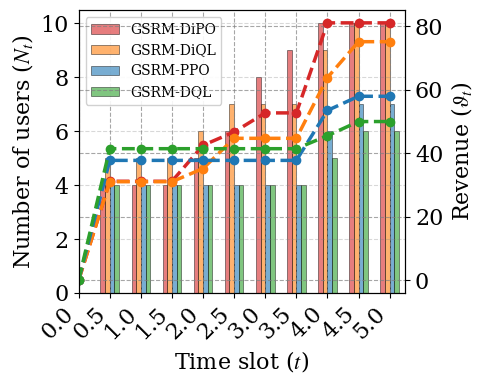

✓ Plot 1 saved as 'plot1_users_revenue.png'


In [63]:
# Plot 1: Number of users (bar) + Revenue (line)
fig, ax1 = plt.subplots(figsize=(5, 4))

# Find maximum length across all agents and pad shorter data
max_len = max(len(agent_dynamics[agent]['users_served']) for agent in agent_dynamics.keys())
timesteps = agent_dynamics['gaussian_dql']['timesteps']
# Extend timesteps if needed
if len(timesteps) < max_len:
    step = timesteps[-1] - timesteps[-2] if len(timesteps) > 1 else 0.5
    timesteps = timesteps + [timesteps[-1] + step * (i+1) for i in range(max_len - len(timesteps))]

n_timesteps = max_len
x_pos = np.arange(n_timesteps)
bar_width = 0.15

def pad_data(data, target_len):
    """Pad data to target length by repeating last value"""
    if len(data) >= target_len:
        return data[:target_len]
    return data + [data[-1]] * (target_len - len(data))

for i, agent_name in enumerate(agent_dynamics.keys()):
    offset = (i - 1.5) * bar_width
    users_padded = pad_data(agent_dynamics[agent_name]['users_served'], max_len)
    ax1.bar(
        x_pos + offset,
        users_padded,
        width=bar_width,
        color=COLOR_SCHEME_1[agent_name],
        alpha=0.6,
        edgecolor='black',
        linewidth=0.5,
        label=f"{agent_names_display[agent_name]}"
    )

ax1.set_xlabel('Time slot ($t$)')
ax1.set_ylabel('Number of users ($N_{t}$)', color='black')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'{t:.1f}' for t in timesteps[:max_len]], rotation=45, ha='right')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3, linestyle='--', axis='y')

ax1_twin = ax1.twinx()
for agent_name in agent_dynamics.keys():
    revenues_padded = pad_data(agent_dynamics[agent_name]['revenues'], max_len)
    ax1_twin.plot(
        x_pos,
        revenues_padded,
        marker='o',
        linewidth=2.5,
        markersize=6,
        linestyle='--',
        color=COLOR_SCHEME_1[agent_name]
    )
ax1_twin.set_ylabel(r'Revenue ($\vartheta_{t}$)', color='black')
ax1_twin.tick_params(axis='y', labelcolor='black')

ax1.legend(loc='upper left', fontsize=10, frameon=True)
ax1.set_xlim(0, n_timesteps - 0.5)

plt.tight_layout()
plt.savefig('plot1_users_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 1 saved as 'plot1_users_revenue.png'")

In [64]:
agent_dynamics.keys()

save_name = f"agent_dynamics_{qos_requirement}_{num_users}_{tau}.json"
with open(save_name, 'w') as f:
    json.dump(agent_dynamics, f, indent=4)


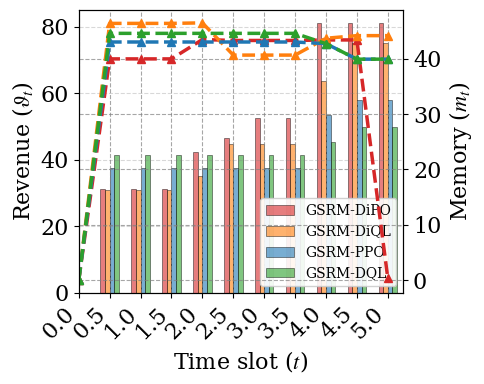

✓ Plot 3 saved as 'plot3_revenue_memory.png'


In [ ]:
# Plot 3: Revenue (bar) + Memory (line)
fig, ax3 = plt.subplots(figsize=(5, 4))

# Find maximum length across all agents and pad shorter data
max_len = max(len(agent_dynamics[agent]['revenues']) for agent in agent_dynamics.keys())
timesteps = agent_dynamics['gaussian_dql']['timesteps']
# Extend timesteps if needed
if len(timesteps) < max_len:
    step = timesteps[-1] - timesteps[-2] if len(timesteps) > 1 else 0.5
    timesteps = timesteps + [timesteps[-1] + step * (i+1) for i in range(max_len - len(timesteps))]

n_timesteps = max_len
x_pos = np.arange(n_timesteps)
bar_width = 0.15

def pad_data(data, target_len):
    """Pad data to target length by repeating last value"""
    if len(data) >= target_len:
        return data[:target_len]
    return data + [data[-1]] * (target_len - len(data))

for i, agent_name in enumerate(agent_dynamics.keys()):
    offset = (i - 1.5) * bar_width
    revenues_padded = pad_data(agent_dynamics[agent_name]['revenues'], max_len)
    ax3.bar(
        x_pos + offset,
        revenues_padded,
        width=bar_width,
        color=COLOR_SCHEME_1[agent_name],
        alpha=0.6,
        edgecolor='black',
        linewidth=0.5,
        label=f"{agent_names_display[agent_name]}"
    )

ax3.set_xlabel('Time slot ($t$)')
ax3.set_ylabel(r'Revenue ($\vartheta_{t}$)', color='black')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([f'{t:.1f}' for t in timesteps[:max_len]], rotation=45, ha='right')
ax3.tick_params(axis='y', labelcolor='black')
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')

ax3_twin = ax3.twinx()
for agent_name in agent_dynamics.keys():
    memory_padded = pad_data(agent_dynamics[agent_name]['current_memory'], max_len)
    ax3_twin.plot(
        x_pos,
        memory_padded,
        marker='^',
        linewidth=2.5,
        markersize=6,
        linestyle='--',
        color=COLOR_SCHEME_1[agent_name]
    )

ax3_twin.set_ylabel('Memory ($m_{t}$)', color='black')
ax3_twin.tick_params(axis='y', labelcolor='black')

ax3.legend(loc='lower right', fontsize=10, frameon=True)
ax3.set_xlim(0, n_timesteps - 0.5)
plt.tight_layout()
plt.savefig('plot3_revenue_memory.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 3 saved as 'plot3_revenue_memory.png'")

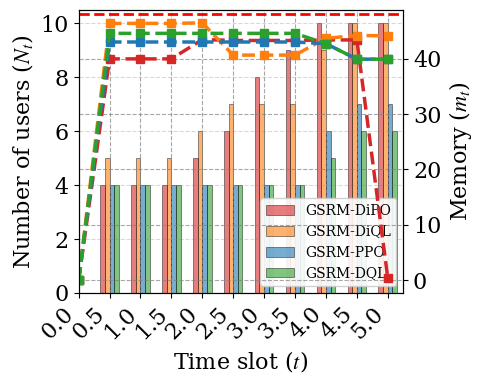

✓ Plot 2 saved as 'plot2_users_memory.png'


In [66]:
# Plot 2: Number of users (bar) + Memory (line)
fig, ax2 = plt.subplots(figsize=(5, 4))

# Find maximum length across all agents and pad shorter data
max_len = max(len(agent_dynamics[agent]['users_served']) for agent in agent_dynamics.keys())
timesteps = agent_dynamics['gaussian_dql']['timesteps']
# Extend timesteps if needed
if len(timesteps) < max_len:
    step = timesteps[-1] - timesteps[-2] if len(timesteps) > 1 else 0.5
    timesteps = timesteps + [timesteps[-1] + step * (i+1) for i in range(max_len - len(timesteps))]

n_timesteps = max_len
x_pos = np.arange(n_timesteps)
bar_width = 0.15

def pad_data(data, target_len):
    """Pad data to target length by repeating last value"""
    if len(data) >= target_len:
        return data[:target_len]
    return data + [data[-1]] * (target_len - len(data))

for i, agent_name in enumerate(agent_dynamics.keys()):
    offset = (i - 1.5) * bar_width
    users_padded = pad_data(agent_dynamics[agent_name]['users_served'], max_len)
    ax2.bar(
        x_pos + offset,
        users_padded,
        width=bar_width,
        color=COLOR_SCHEME_1[agent_name],
        alpha=0.6,
        edgecolor='black',
        linewidth=0.5,
        label=f"{agent_names_display[agent_name]}"
    )

ax2.set_xlabel('Time slot ($t$)')
ax2.set_ylabel('Number of users ($N_{t}$)', color='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'{t:.1f}' for t in timesteps[:max_len]], rotation=45, ha='right')
ax2.tick_params(axis='y', labelcolor='black')
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')

ax2_twin = ax2.twinx()
for agent_name in agent_dynamics.keys():
    memory_padded = pad_data(agent_dynamics[agent_name]['current_memory'], max_len)
    ax2_twin.plot(
        x_pos,
        memory_padded,
        marker='s',
        linewidth=2.5,
        markersize=6,
        linestyle='--',
        color=COLOR_SCHEME_1[agent_name]
    )
ax2_twin.set_ylabel('Memory ($m_{t}$)', color='black')
ax2_twin.tick_params(axis='y', labelcolor='black')
ax2_twin.axhline(y=48, color='red', linestyle='--', linewidth=2, label='Max Capacity')
ax2.legend(loc='lower right', fontsize=10, frameon=True)
ax2.set_xlim(0, n_timesteps - 0.5)
plt.tight_layout()
plt.savefig('plot2_users_memory.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 2 saved as 'plot2_users_memory.png'")

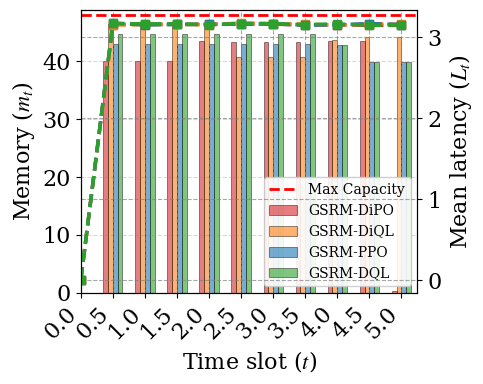

✓ Plot 4 saved as 'plot4_latency_memory.png'


In [67]:
# Plot 4: Mean Latency (bar) + Memory (line)
fig, ax4 = plt.subplots(figsize=(5, 4))

# Find maximum length across all agents and pad shorter data
max_len = max(len(agent_dynamics[agent]['mean_latency']) for agent in agent_dynamics.keys())
timesteps = agent_dynamics['gaussian_dql']['timesteps']
# Extend timesteps if needed
if len(timesteps) < max_len:
    step = timesteps[-1] - timesteps[-2] if len(timesteps) > 1 else 0.5
    timesteps = timesteps + [timesteps[-1] + step * (i+1) for i in range(max_len - len(timesteps))]

n_timesteps = max_len
x_pos = np.arange(n_timesteps)
bar_width = 0.15

def pad_data(data, target_len):
    """Pad data to target length by repeating last value"""
    if len(data) >= target_len:
        return data[:target_len]
    return data + [data[-1]] * (target_len - len(data))

for i, agent_name in enumerate(agent_dynamics.keys()):
    offset = (i - 1.5) * bar_width
    latency_padded = pad_data(agent_dynamics[agent_name]['current_memory'], max_len)
    ax4.bar(
        x_pos + offset,
        latency_padded,
        width=bar_width,
        color=COLOR_SCHEME_1[agent_name],
        alpha=0.6,
        edgecolor='black',
        linewidth=0.5,
        label=f"{agent_names_display[agent_name]}"
    )
ax4.axhline(y=48, color='red', linestyle='--', linewidth=2, label='Max Capacity')
ax4.set_xlabel('Time slot ($t$)')
ax4.set_ylabel('Memory ($m_{t}$)', color='black')
ax4.set_xticks(x_pos)
ax4.set_xticklabels([f'{t:.1f}' for t in timesteps[:max_len]], rotation=45, ha='right')
ax4.tick_params(axis='y', labelcolor='black')
ax4.grid(True, alpha=0.3, linestyle='--', axis='y')

ax4_twin = ax4.twinx()
for agent_name in agent_dynamics.keys():
    memory_padded = pad_data(agent_dynamics[agent_name]['mean_latency'], max_len)
    ax4_twin.plot(
        x_pos,
        memory_padded,
        marker='s',
        linewidth=2.5,
        markersize=6,
        linestyle='--',
        color=COLOR_SCHEME_1[agent_name]
    )
ax4_twin.set_ylabel('Mean latency ($L_{t}$)', color='black')
ax4_twin.tick_params(axis='y', labelcolor='black')
ax4.legend(loc='lower right', fontsize=10, frameon=True)
ax4.set_xlim(0, n_timesteps - 0.5)
plt.tight_layout()
plt.savefig('plot4_latency_memory.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 4 saved as 'plot4_latency_memory.png'")

✓ Memory dynamics plot saved as 'memory_dynamics_all_agents.png'


/tmp/ipykernel_210275/4261353012.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


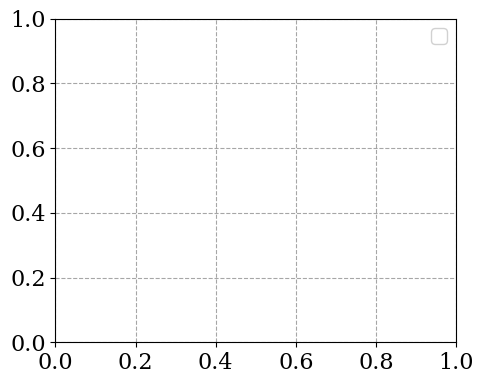

In [68]:
# Memory Dynamics: Current vs Peak Memory for all agents
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# axes = axes.flatten()

# Find maximum length and pad data
max_len = max(len(agent_dynamics[agent]['current_memory']) for agent in agent_dynamics.keys())
timesteps = agent_dynamics['gaussian_dql']['timesteps']
# Extend timesteps if needed
if len(timesteps) < max_len:
    step = timesteps[-1] - timesteps[-2] if len(timesteps) > 1 else 0.5
    timesteps = timesteps + [timesteps[-1] + step * (i+1) for i in range(max_len - len(timesteps))]

def pad_data(data, target_len):
    """Pad data to target length by repeating last value"""
    if len(data) >= target_len:
        return data[:target_len]
    return data + [data[-1]] * (target_len - len(data))



for idx, agent_name in enumerate(agent_dynamics.keys()):
    
    
    # Pad data to match maximum length
    current_mem_padded = pad_data(agent_dynamics[agent_name]['current_memory'], max_len)
    peak_mem_padded = pad_data(agent_dynamics[agent_name]['peak_memory'], max_len)
    
    # Fill between for current memory
    plt.fill_between(timesteps[:max_len], 0, current_mem_padded, 
                   alpha=0.3, color=COLOR_SCHEME_1[agent_name], 
                   label='Current Memory Usage')
    
    # Plot current memory
    plt.plot(timesteps[:max_len], current_mem_padded, 'o-', 
           color=COLOR_SCHEME_1[agent_name], linewidth=2.5, markersize=7, 
           label=f'Current Memory')
    
    # Plot peak memory
    plt.plot(timesteps[:max_len], peak_mem_padded, 's--', 
           color='#D62246', linewidth=2.5, markersize=7, label='Peak Memory')
    
    # Memory limit line
    plt.axhline(y=48, color='red', linestyle='--', linewidth=2, 
              label='Memory Limit (48 GB)', alpha=0.7)
    
    plt.xlabel('Time slot ($t$)')
    plt.ylabel('Memory ($m_{t}$)')
#     ax.set_title(f'Memory Dynamics: {agent_names_display[agent_name]}', 
              #   fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(fontsize=14, loc='best', frameon=True)
    plt.ylim(0, 50)
    plt.xticks(timesteps[:max_len])
    plt.gca().set_xticklabels([f'{t:.1f}' for t in timesteps[:max_len]], rotation=45, ha='right')
    plt.xlim(timesteps[0], timesteps[max_len-1])
    plt.savefig(f'memory_dynamics_all_agents_{agent_name}.png', dpi=300, bbox_inches='tight')
    plt.close()
# plt.suptitle('Memory Usage Dynamics: Current vs Peak - All Agents', 
       #      fontsize=15, y=0.995)
plt.legend()
plt.tight_layout()
# plt.savefig('memory_dynamics_all_agents.png', dpi=300, bbox_inches='tight')
# plt.show()

print("✓ Memory dynamics plot saved as 'memory_dynamics_all_agents.png'")